Реализовать алгоритм K-means с учётом радиуса кластера (до 6.03).
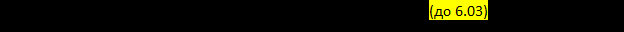
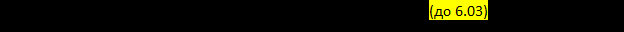

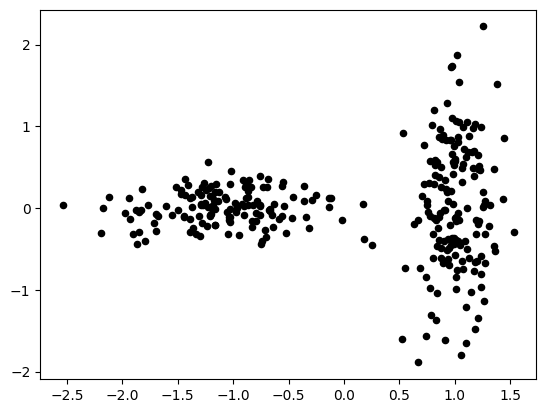

In [12]:
import matplotlib.pyplot as plt
import random
from math import sqrt
from math import sin
from math import cos

POINT_N = 300
CLUST_N = 2
K = 3

def DataClouds (A, N):
	for i in range(N):
		if random.random() < 0.5:
			A[i].clust = 0
			A[i].X = random.normalvariate(-1.0, 0.5)
			A[i].Y = random.normalvariate(0.0, 0.2)
		else:
			A[i].clust = 1
			A[i].X = random.normalvariate(1.0, 0.2)
			A[i].Y = random.normalvariate(0.0, 0.75)
	return

def DataMoons (A, N):
	for i in range(N):
		f = 3.14 * random.random()
		r = 0.2 * random.normalvariate(0.0, 0.4) + 0.9
		if random.random() < 0.5:
			A[i].clust = 0
			A[i].X = 0.5 + r * cos(f)
			A[i].Y = -0.25 + r * sin(f)
		else:
			A[i].clust = 1
			A[i].X = -0.5 + r * cos(f)
			A[i].Y = 0.25 - r * sin(f)
	return

class POINT:
    def __init__(self, cl, x, y):
        self.clust = cl
        self.X = x
        self.Y = y

class CLUSTER(POINT):
    def __init__(self, cl, x, y):
        POINT.__init__(self, cl, x, y)
        self.N = 0
    def Dist(self, p):
        return sqrt( (self.X - p.X)**2 + (self.Y - p.Y)**2 )
    def Eval_Center(self, P):
        self.N = 0
        self.X = 0.0
        self.Y = 0.0
        for p in P:
            if p.clust == self.clust:
                self.N += 1
                self.X += p.X
                self.Y += p.Y
        self.X /= self.N
        self.Y /= self.N
        #мое
    def delta(self, P):
        n = 0
        sum = 0.0
        for p in P:
            if p.clust == self.clust:
                n+=1
                sum += (self.X - p.X)**2 + (self.Y - p.Y)**2
        return sum/n
    def radius(self, P):
        return sqrt(K * self.delta(P))








Cl = [CLUSTER(0, 2.0*random.random()-1.0, 2.0*random.random()-1.0), CLUSTER(1, 2.0*random.random()-1.0, 2.0*random.random()-1.0)]

PP = [POINT(CLUST_N, 0.0, 0.0) for i in range(POINT_N)]

DataClouds(PP, POINT_N)
#DataMoons(PP, POINT_N)

for p in PP:
    plt.scatter(p.X, p.Y, c='black', s=20)
plt.show()

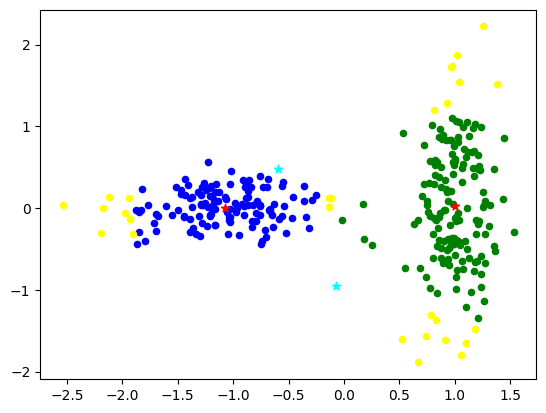

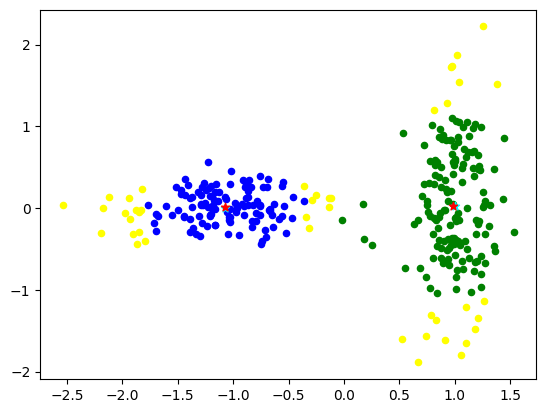

In [13]:
while (1):
    CC = [POINT(0, Cl[0].X, Cl[0].Y), POINT(1, Cl[1].X, Cl[1].Y)]




    for cl in Cl:
        cl.Eval_Center(PP)

    for p in PP:
        if Cl[0].Dist(p) < Cl[1].Dist(p) and Cl[0].Dist(p) < Cl[0].radius(PP):
            p.clust = 0
            plt.scatter(p.X, p.Y, c='blue', s=20)
        elif Cl[0].Dist(p) > Cl[1].Dist(p) and Cl[1].Dist(p) < Cl[1].radius(PP):
            p.clust = 1
            plt.scatter(p.X, p.Y, c='green', s=20)
        else :
            p.clust = -1
            plt.scatter(p.X, p.Y, c='yellow', s=20)
    for cl in Cl:
            plt.scatter(CC[cl.clust].X, CC[cl.clust].Y, c='cyan', marker="*")
            plt.scatter(cl.X, cl.Y, c='red', marker="*")
    plt.show()

    if (Cl[0].Dist(CC[0]) + Cl[1].Dist(CC[1])) < 0.1:
        break
